<a href="https://colab.research.google.com/github/Skillstomorrow83/Data_Loves_Python/blob/main/%D0%94%D0%97_HW3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - сезон (1=весна, 2=літо, 3=осінь, 4=зима)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/DataLoves/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [4]:
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'date', 'day',
       'week', 'weekday_num', 'weekday', 'year', 'month', 'hour'],
      dtype='object')

In [5]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [6]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

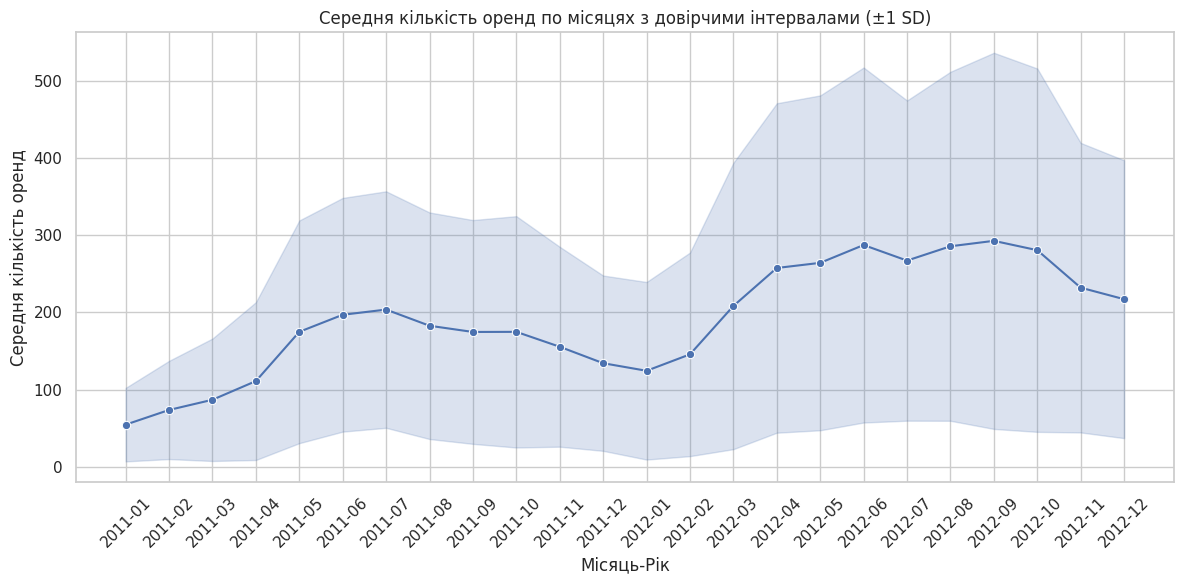

''

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    estimator='mean',
    errorbar ='sd',  # довірчий інтервал = 1 стандартне відхилення
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Середня кількість оренд по місяцях з довірчими інтервалами (±1 SD)')
plt.xlabel('Місяць-Рік')
plt.ylabel('Середня кількість оренд')
plt.tight_layout()
plt.show()
;

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

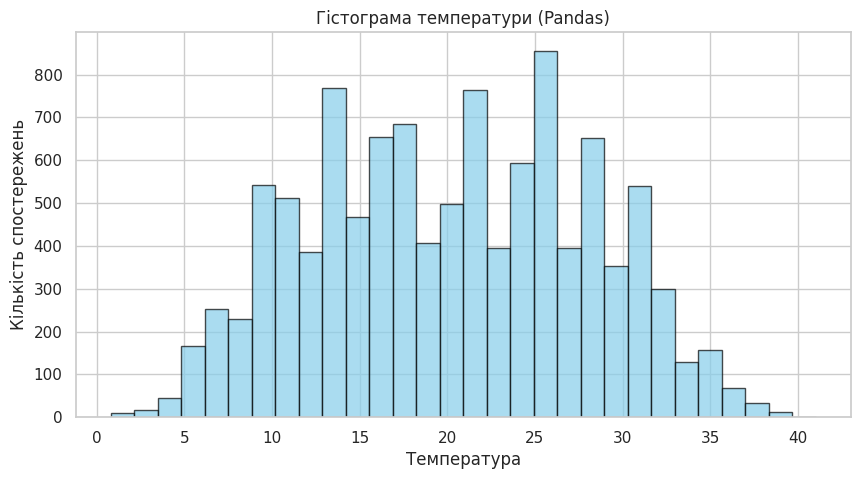

In [8]:
#Pandas
plt.figure(figsize=(10, 5))
df['temp'].plot.hist(bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Гістограма температури (Pandas)')
plt.xlabel('Температура')
plt.ylabel('Кількість спостережень')
plt.grid(True)
plt.show()


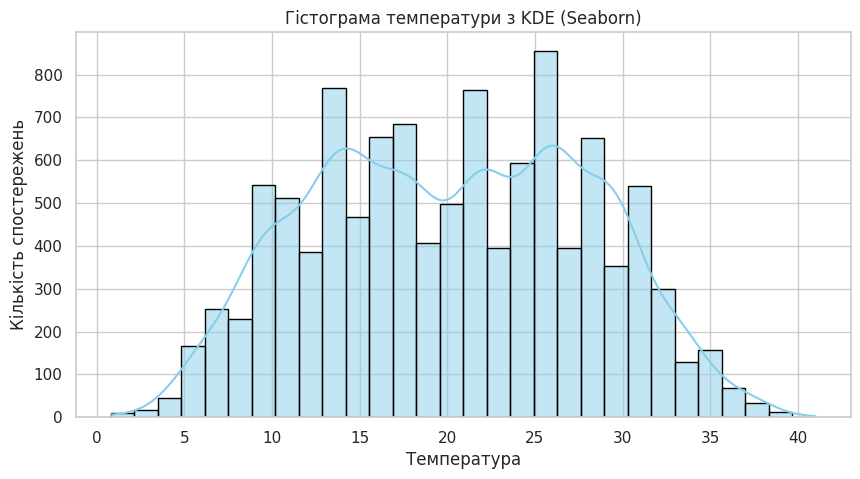

In [9]:
#Seaborn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='temp', bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Гістограма температури з KDE (Seaborn)')
plt.xlabel('Температура')
plt.ylabel('Кількість спостережень')
plt.grid(True)
plt.show()


Візуально графіки виглядають майже однаково (Seaborn трохи гладкіший).

В Pandas більш простий синтаксис, менше контролю над стилем, немає автоматичного згладжування.

В Seaborn більш естетичний вигляд, більше параметрів для стилізації. Додається крива KDE — це оцінка щільності розподілу, тобто це крива, яка замінює гістограму або може накладатися на неї.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

<Figure size 1000x500 with 0 Axes>

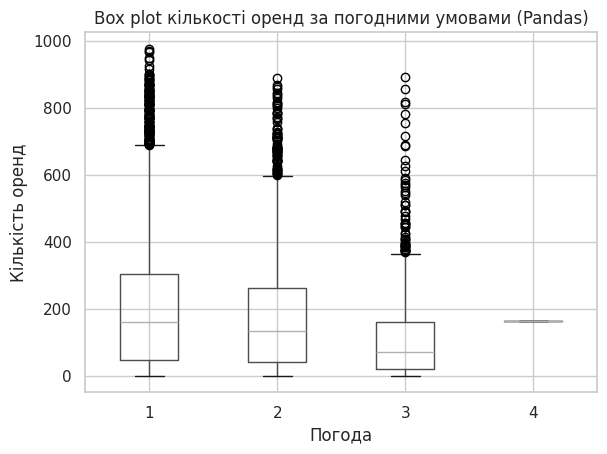

In [10]:
#Pandas
plt.figure(figsize=(10, 5))
df.boxplot(column='count', by='weather')
plt.title('Box plot кількості оренд за погодними умовами (Pandas)')
plt.suptitle('')
plt.xlabel('Погода')
plt.ylabel('Кількість оренд')
plt.grid(True)
plt.show();


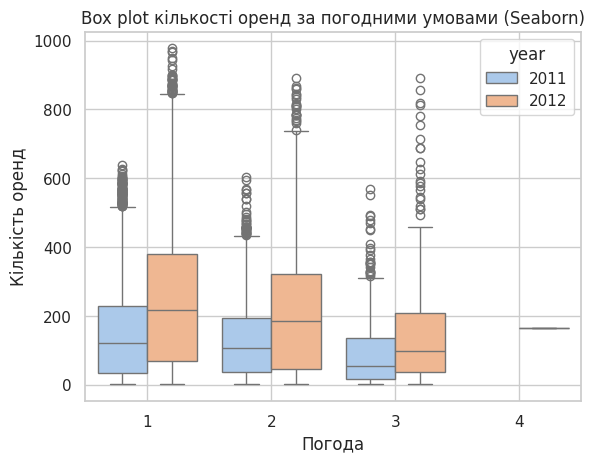

In [11]:
#Seaborn
sns.boxplot(data=df, x='weather', y='count', palette='pastel', hue="year")
plt.title('Box plot кількості оренд за погодними умовами (Seaborn)')
plt.xlabel('Погода')
plt.ylabel('Кількість оренд')
plt.grid(True)
plt.show();


Pandas Boxplot має більш аскетичний вигляд, натомість Seaborn має гнучке налаштування кольорів, стилів, сортування, кобмбінування графіків. Наприклад можно параметром hue додавати ще один "вимір" даних з датасету.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [20]:
sns.set(style="whitegrid")

# Вибір лише числових колонок
numeric_df = df.select_dtypes(include='number')
# Обчислення кореляційної матриці
correlation = numeric_df.corr()


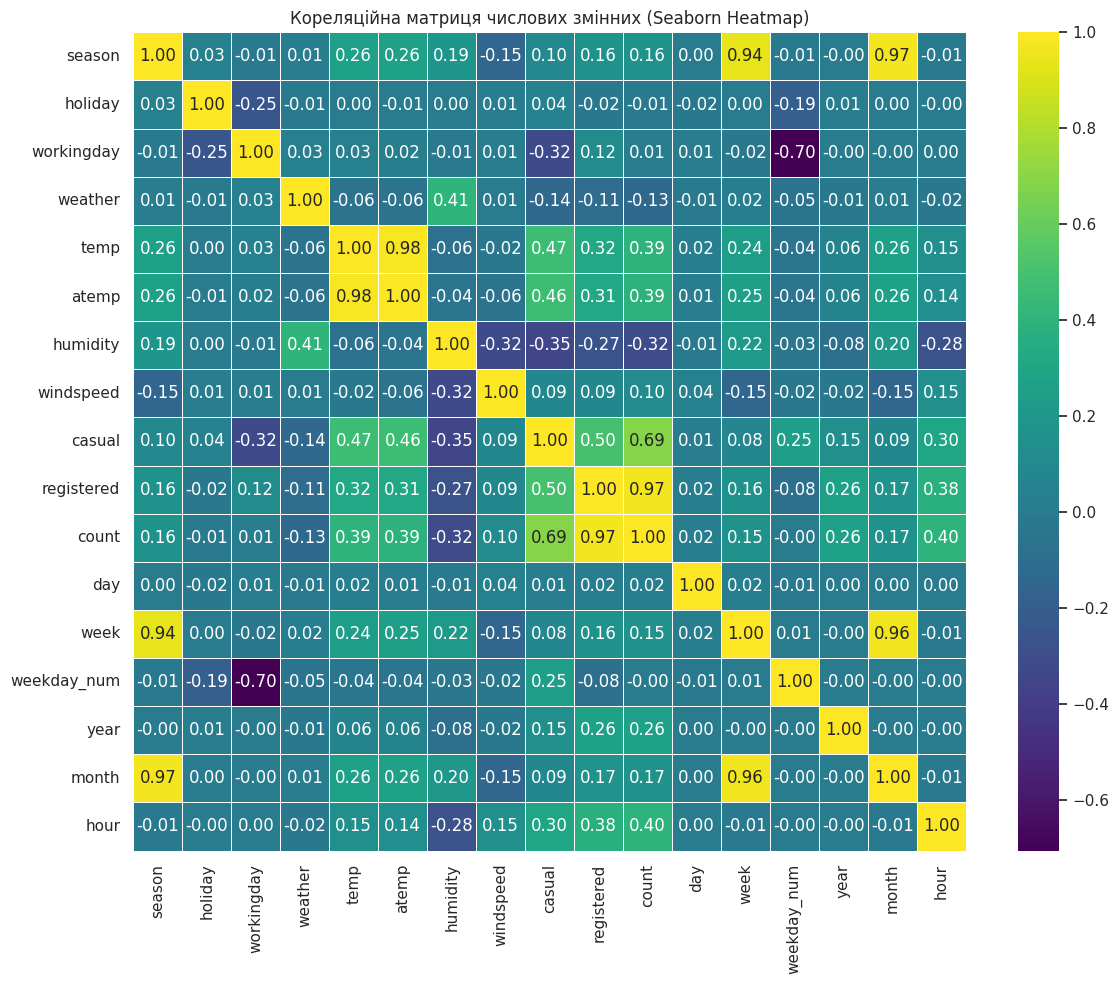

In [28]:
# Побудова heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",         # Форматування чисел
    cmap='viridis',    # Колірна палітра
    linewidths=0.5     # Лінії між клітинками
)
plt.title('Кореляційна матриця числових змінних (Seaborn Heatmap)')
plt.tight_layout()
plt.show()



1) Зареєстровані користувачі — основні орендарі (0,97), випадкові користувачі теж впливають(0,69).

З кількістю оренд також корелюють: температура (temp та atemp), також година доби (0,39-0,4).

2) Кореляція ~0,98 temp i atemp. В реальності вони майже ідентичні, тому й така сильна кореляція.

3) Негативно корелюють:
workingday та weekday_num - зрозуміло, бо це дні тижня;
casual та workingday - похоже випадкові користувачі частіше орендують у вихідні дні;
humidity	негативно корелює (-0.30)	з бажанням орендувати count,
з windspeed	(-0.32) по природним причинам, з кількістю оренд (-0,32) та типами користувачів (0,35 та 0,27).


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за сезонами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому сезоні найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


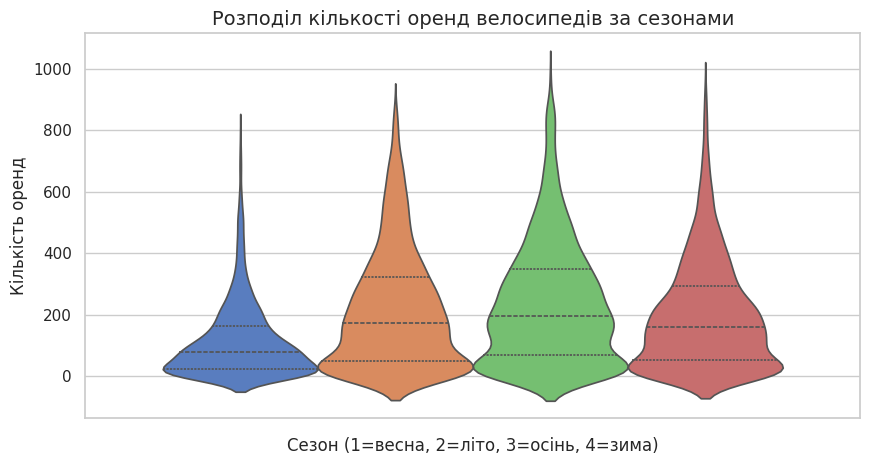

In [50]:
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    hue='season',
    y='count',
    legend=False,
    palette='muted',
    inner='quartile'
)

plt.title('Розподіл кількості оренд велосипедів за сезонами', fontsize=14)
plt.xlabel('Сезон (1=весна, 2=літо, 3=осінь, 4=зима)')
plt.ylabel('Кількість оренд')
plt.show();


1) Товщина на певному рівні осі Y означає густину даних — наскільки часто трапляються значення оренд у цьому діапазоні.
Широка частина “скрипки” = більше днів з такою кількістю оренд.

2) Сезон з найвищим розкидом по вертикалі та з багатьма "товстими" ділянками показує найбільшу варіабельність. Тобто це 3й сезон - висока й широка скрипка.

3) Box Plot показує лише медіану, квартилі та викиди, тобто менш детально відображає форму розподілу, а Violin Plot дає повну картину розподілу та густини значень, можна побачити, чи є пік лише в одному місці чи кілька мод, підходить для глибшого аналізу, особливо при складних чи багатомодових розподілах.

## Завдання 6: Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте сезон.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше змінюється від сезону?

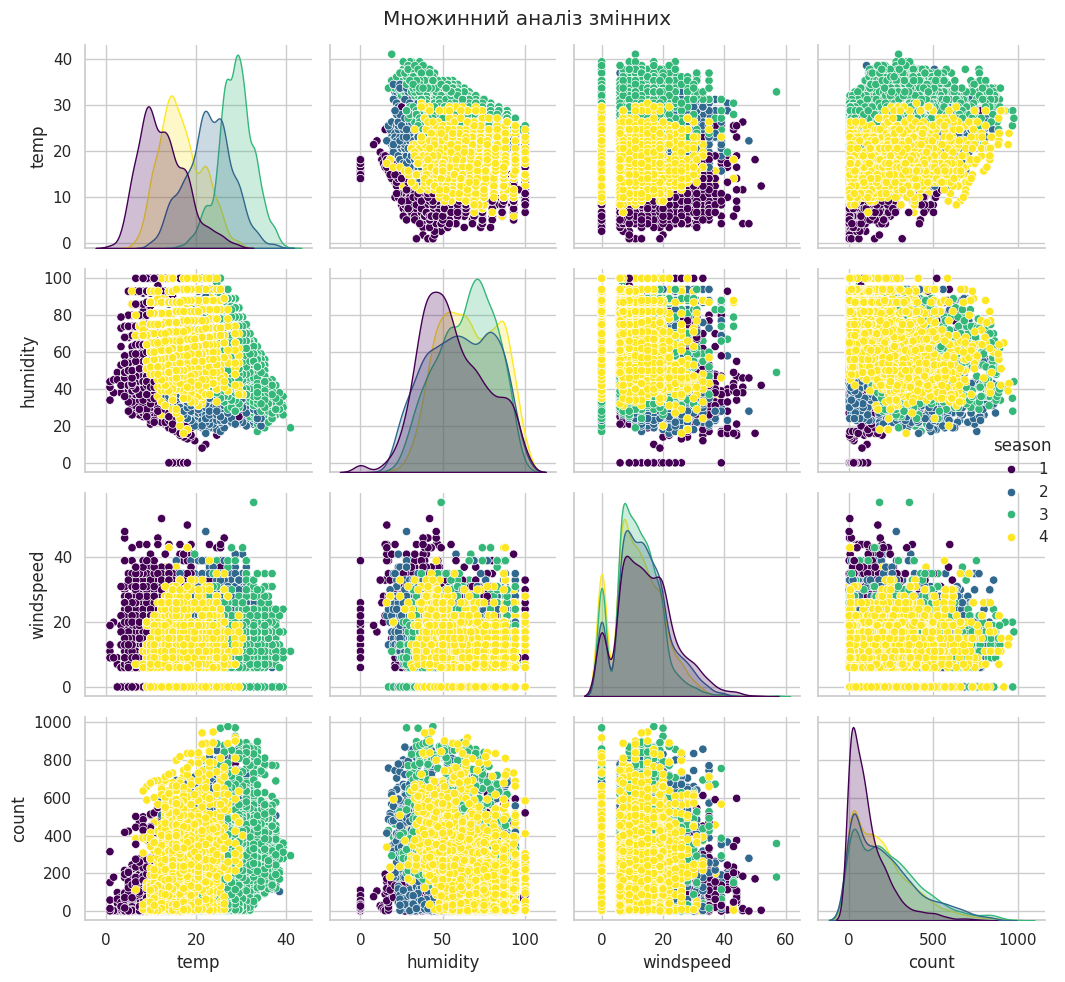

In [60]:
df_selected = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(df_selected, hue='season', palette='viridis', diag_kind='kde')
plt.suptitle('Множинний аналіз змінних')
plt.tight_layout()
plt.show()


Найсильніший лінійний зв’язок зазвичай спостерігається між temp і count — теплі дні стимулюють більше оренд.

Найбільша сезонна варіація помітна у temp.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

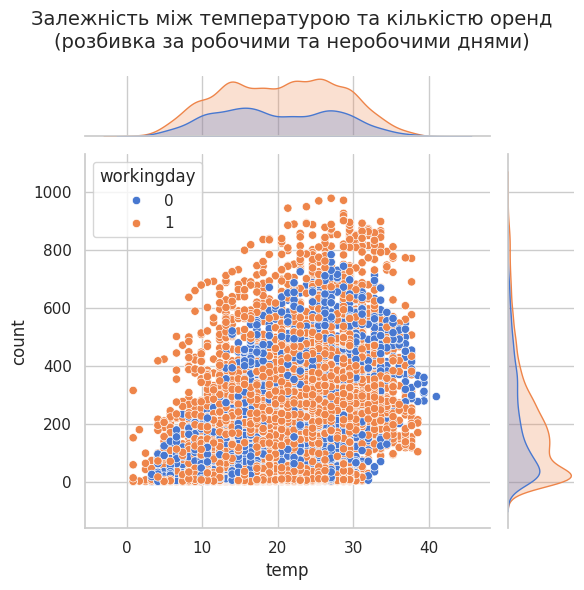

In [63]:
sns.jointplot(
    data=df,
    x="temp",
    y="count",
    hue="workingday",
    palette="muted",
    kind="scatter"
)
plt.suptitle("Залежність між температурою та кількістю оренд\n(розбивка за робочими та неробочими днями)",
    fontsize=14
)
plt.tight_layout()
plt.show()


1) По обидва краї від основного поля розташовані одновимірні розподіли (KDE-графіки):

Угорі — розподіл температури (temp) для кожної категорії workingday. Це показує, які температури найчастіше спостерігаються в робочі й неробочі дні.

Праворуч — розподіл кількості оренд (count) у кожній групі. Тут легко побачити, при яких значеннях попит на велосипеди найвищий.

Ці графіки дозволяють оцінити форму розподілу, виявити піки та варіативність у кожній категорії.

2) Так, різниця помітна: температура впливає на попит у будь-який день, але в неробочі — ефект сильніший через відсутність робочих обмежень та більше вільного часу.
